Descargando datos financieros...


[*********************100%***********************]  3 of 3 completed


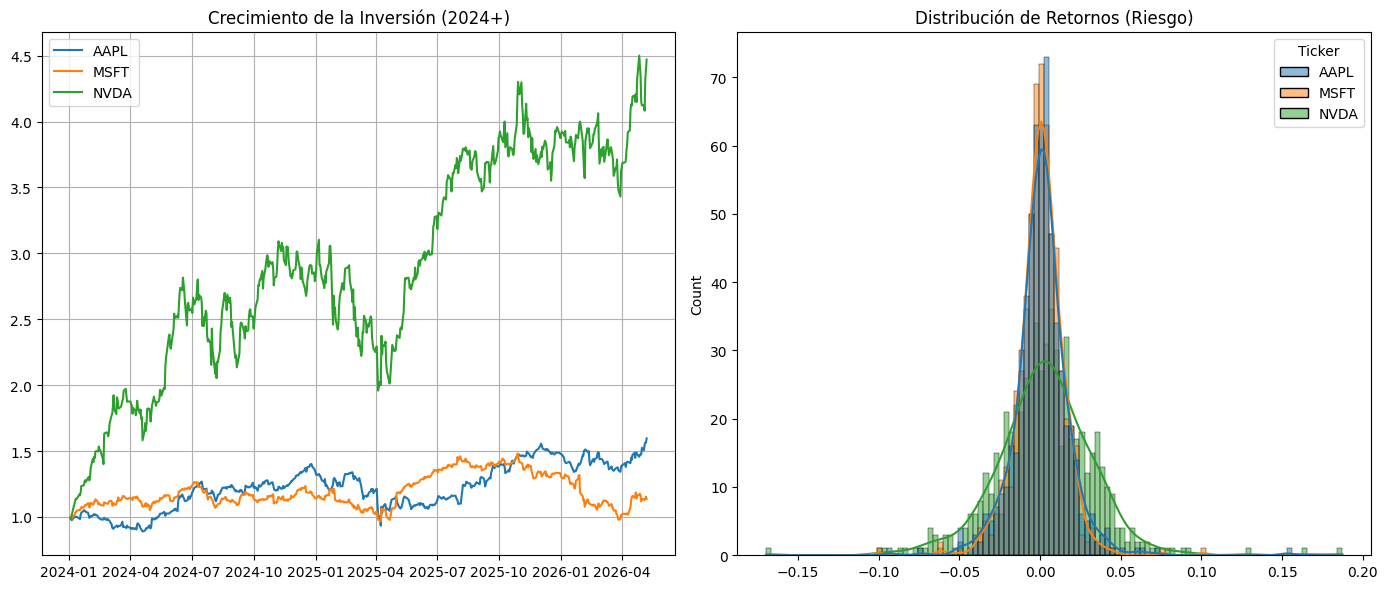


--- REPORTE DE CALIDAD ---
Ticker        AAPL        MSFT        NVDA
count   590.000000  590.000000  590.000000
mean    225.171113  434.539518  139.229982
std      31.404822   44.016766   39.575487
min     163.511917  351.866241   47.539936
25%     201.316322  403.785591  112.741201
50%     225.638725  419.862274  135.765854
75%     251.767521  471.591110  178.365395
max     293.320007  539.825256  216.610001


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selección de 3 activos
activos = ['NVDA', 'AAPL', 'MSFT']
print("Descargando datos financieros...")

# Forma segura de descargar precios ajustados
df = yf.download(activos, start="2024-01-01")

# Si el archivo tiene varias capas, buscamos el precio de cierre
if 'Adj Close' in df.columns:
    df = df['Adj Close']
else:
    # A veces se llama simplemente 'Close'
    df = df['Close']

# 2. Cálculo de Retornos
retornos = df.pct_change().dropna()
acumulados = (1 + retornos).cumprod()

# 3. Gráficos
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for activo in acumulados.columns:
    plt.plot(acumulados.index, acumulados[activo], label=activo)
plt.title('Crecimiento de la Inversión (2024+)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(retornos, kde=True)
plt.title('Distribución de Retornos (Riesgo)')

plt.tight_layout()
plt.show()

# 4. Reporte final
print("\n--- REPORTE DE CALIDAD ---")
print(df.describe())